In [1]:
import os
import time
import warnings
from collections import defaultdict

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
%matplotlib inline

from sgimc.utils import save, load

import pandas as pd

In [83]:
METRIC_INDEX = {
    "aupr": 0,
    "auc": 1,
    "f1": 2,
    "acc": 3,
    "recall": 4,
    "specificity": 5,
    "precision": 6,
}

import numpy as np
from collections import defaultdict


def get_final_results(results, param="train_size", hyp_param="xi", target="auc"):

    metric_idx = METRIC_INDEX[target]

    # =====================================================
    # 1️⃣ group by (train_size, xi) → average over CV
    # =====================================================
    by_combo = defaultdict(list)

    for r in results:
        key = (r[param], r[hyp_param])
        by_combo[key].append(r)

    results_avg = []

    for (ts, xi), group in by_combo.items():
        val_vals = [g["val_score"][metric_idx] for g in group]
        test_vals = [g["test_score"][metric_idx] for g in group]

        results_avg.append(
            [
                ts,  # train_size
                xi,  # xi
                np.nanmax(val_vals),  # val metric
                np.nanmax(test_vals),  # test metric
            ]
        )

    results_avg = np.array(results_avg)
    # columns: [train_size, xi, val_metric, test_metric]

    # =====================================================
    # 2️⃣ group by train_size → select best xi
    # =====================================================
    by_train = defaultdict(list)

    for row in results_avg:
        by_train[row[0]].append(row)

    results_final = []

    for ts, rows in by_train.items():
        rows = np.array(rows)
        best = rows[np.nanargmax(rows[:, 2])]  # max validation metric
        results_final.append(best[[0, 3]])  # (train_size, test_metric)

    results_final = np.array(results_final)

    # =====================================================
    # 3️⃣ sort for plotting + sanity check
    # =====================================================
    order = np.argsort(results_final[:, 0])
    results_final = results_final[order]

    assert len(np.unique(results_final[:, 0])) == results_final.shape[0]

    return results_final.T

In [195]:
METRIC_INDEX = {
    "aupr": 0,
    "auc": 1,
    "f1": 2,
    "acc": 3,
    "recall": 4,
    "specificity": 5,
    "precision": 6,
}

import numpy as np
from collections import defaultdict


def get_test_results(results, param="train_size", hyp_param="xi", target="auc"):

    metric_idx = METRIC_INDEX[target]

    # =====================================================
    # 1️⃣ group by (train_size, xi) → average over CV
    # =====================================================
    by_combo = defaultdict(list)

    for r in results:
        key = (r[param], r[hyp_param])
        by_combo[key].append(r)

    results_avg = []

    for (ts, xi), group in by_combo.items():
        # val_vals = [g["val_score"][metric_idx] for g in group]
        test_vals = [g["test_score"][metric_idx] for g in group]

        results_avg.append(
            [
                ts,  # train_size
                xi,  # xi
                # np.nanmean(val_vals),        # val metric
                np.nanmean(test_vals),  # test metric
            ]
        )

    results_avg = np.array(results_avg)
    # columns: [train_size, xi, val_metric, test_metric]

    # =====================================================
    # 2️⃣ group by train_size → select best xi
    # =====================================================
    by_train = defaultdict(list)

    for row in results_avg:
        by_train[row[0]].append(row)

    results_final = []

    for ts, rows in by_train.items():
        rows = np.array(rows)
        best = rows[np.nanargmax(rows[:, 2])]  # max validation metric
        results_final.append(best[[0, 2]])  # (train_size, test_metric)

    results_final = np.array(results_final)

    # =====================================================
    # 3️⃣ sort for plotting + sanity check
    # =====================================================
    order = np.argsort(results_final[:, 0])
    results_final = results_final[order]

    assert len(np.unique(results_final[:, 0])) == results_final.shape[0]

    return results_final.T

## Case 1: separate

In [9]:
PATH_ROOT = "/Users/sijianfan/projects/BiSSGL"
PATH_DATA = os.path.join(PATH_ROOT, "datasets/realAnalysis/cdataset/cv_data")

PATH_OUTPUT = os.path.join(PATH_ROOT, "outputs/results/realAnalysis/cdataset/separate")

if not os.path.isdir(PATH_OUTPUT):
    os.makedirs(PATH_OUTPUT)

PATH_ARCHIVE = os.path.join(PATH_OUTPUT, "archived")
if not os.path.isdir(PATH_ARCHIVE):
    os.makedirs(PATH_ARCHIVE)

### BiSSGL

In [10]:
filename_results = []
filename_results.append(os.path.join(PATH_OUTPUT, "results_bissgl.gz"))

# for fn in os.listdir(PATH_ARCHIVE):
#     filename_results.append(os.path.join(PATH_ARCHIVE, fn))

filename_results

['/Users/sijianfan/projects/BiSSGL/outputs/results/realAnalysis/cdataset/separate/results_bissgl.gz']

In [11]:
results = []
for fn in filename_results:
    results.append(load(fn))

In [12]:
results

[[{'combo_idx': 0,
   'train_size': 0.1,
   'xi': 1,
   'eta': 1e-06,
   'tilde_lambda0': 5,
   'tilde_lambda1': 1,
   'lambda0': 5,
   'lambda1': 1,
   'K': 50,
   'cv': 0,
   'val_score': [0.5035296303176667,
    0.5,
    0.014019553587898912,
    0.007059260635333457,
    1.0,
    0.0,
    0.007059260635333457],
   'val_d1': 654,
   'val_d2': 0,
   'test_score': [0.505127633485676,
    0.5,
    0.020302328147412556,
    0.010255266971352135,
    1.0,
    0.0,
    0.010255266971352135],
   'test_d1': 88,
   'test_d2': 0},
  {'combo_idx': 0,
   'train_size': 0.1,
   'xi': 1,
   'eta': 1e-06,
   'tilde_lambda0': 5,
   'tilde_lambda1': 1,
   'lambda0': 5,
   'lambda1': 1,
   'K': 50,
   'cv': 1,
   'val_score': [0.5046442504179826,
    0.5,
    0.018406037180195105,
    0.009288500835965075,
    1.0,
    0.0,
    0.009288500835965075],
   'val_d1': 187,
   'val_d2': 0,
   'test_score': [0.505127633485676,
    0.5,
    0.020302328147412556,
    0.010255266971352135,
    1.0,
    0.0,
   

In [14]:
results_bissgl = get_final_results(
    results[0],
    param="train_size",
    hyp_param="xi",
    target="auc",
)

In [15]:
results_bissgl

array([[0.1       , 0.2       , 0.3       , 0.4       , 0.5       ,
        0.6       , 0.7       , 0.8       ],
       [0.51943741, 0.52696324, 0.54163308, 0.55431279, 0.58701519,
        0.59050554, 0.59037848, 0.6261624 ]])

### IMC

In [16]:
filename_results = []
filename_results.append(os.path.join(PATH_OUTPUT, "results_imc.gz"))

# for fn in os.listdir(PATH_ARCHIVE):
#     filename_results.append(os.path.join(PATH_ARCHIVE, fn))

filename_results

['/Users/sijianfan/projects/BiSSGL/outputs/results/realAnalysis/cdataset/separate/results_imc.gz']

In [17]:
results = []
for fn in filename_results:
    results.append(load(fn))

In [18]:
results

[[{'train_size': 0.1,
   'lamb': 1.0,
   'rank': 200,
   'cv': 0,
   'val_score': [0.08082744672795797,
    0.6005981623851491,
    0.10416666666666667,
    0.9840237785621401,
    0.1,
    0.9923120195012188,
    0.10869565217391304],
   'test_score': [0.025994590765608498,
    0.5412963790585981,
    0.026905829596412557,
    0.9838739642551927,
    0.024489795918367346,
    0.9926878656067196,
    0.029850746268656716]},
  {'train_size': 0.1,
   'lamb': 1.0,
   'rank': 200,
   'cv': 1,
   'val_score': [0.09791325513158425,
    0.6025019419577481,
    0.1111111111111111,
    0.9762214378599294,
    0.13559322033898305,
    0.9855371900826446,
    0.09411764705882353],
   'test_score': [0.025994590765608498,
    0.5412963790585981,
    0.026905829596412557,
    0.9838739642551927,
    0.024489795918367346,
    0.9926878656067196,
    0.029850746268656716]},
  {'train_size': 0.1,
   'lamb': 1.0,
   'rank': 200,
   'cv': 2,
   'val_score': [0.01943440803150485,
    0.5108945986496624,
 

In [19]:
results_imc = get_final_results(
    results[0],
    param="train_size",
    hyp_param="lamb",
    target="auc",
)
results_imc

array([[0.1       , 0.2       , 0.3       , 0.4       , 0.5       ,
        0.6       , 0.7       , 0.8       ],
       [0.58222589, 0.59108555, 0.63409199, 0.61768457, 0.54435163,
        0.64760724, 0.66308654, 0.6736193 ]])

### SGIMC

In [20]:
filename_results = []
filename_results.append(os.path.join(PATH_OUTPUT, "results_sgimc.gz"))

# for fn in os.listdir(PATH_ARCHIVE):
#     filename_results.append(os.path.join(PATH_ARCHIVE, fn))

filename_results

['/Users/sijianfan/projects/BiSSGL/outputs/results/realAnalysis/cdataset/separate/results_sgimc.gz']

In [21]:
results = []
for fn in filename_results:
    results.append(load(fn))

In [22]:
results

[[{'combo_idx': 0,
   'train_size': 0.1,
   'C_lasso': 5.0,
   'C_group': 5.0,
   'C_ridge': 1.0,
   'cv': 0,
   'val_score': [0.5035296303176667,
    0.5,
    0.014019553587898912,
    0.007059260635333457,
    1.0,
    0.0,
    0.007059260635333457],
   'val_d1': 0,
   'val_d2': 0,
   'test_score': [0.505127633485676,
    0.5,
    0.020302328147412556,
    0.010255266971352135,
    1.0,
    0.0,
    0.010255266971352135],
   'test_d1': 0,
   'test_d2': 0},
  {'combo_idx': 0,
   'train_size': 0.1,
   'C_lasso': 5.0,
   'C_group': 5.0,
   'C_ridge': 1.0,
   'cv': 1,
   'val_score': [0.5046442504179826,
    0.5,
    0.018406037180195105,
    0.009288500835965075,
    1.0,
    0.0,
    0.009288500835965075],
   'val_d1': 0,
   'val_d2': 0,
   'test_score': [0.505127633485676,
    0.5,
    0.020302328147412556,
    0.010255266971352135,
    1.0,
    0.0,
    0.010255266971352135],
   'test_d1': 0,
   'test_d2': 0},
  {'combo_idx': 0,
   'train_size': 0.1,
   'C_lasso': 5.0,
   'C_group': 

In [23]:
results_sgimc = get_final_results(
    results[0],
    param="train_size",
    hyp_param="C_group",
    target="auc",
)

In [24]:
results_sgimc

array([[0.1       , 0.2       , 0.3       , 0.4       , 0.5       ,
        0.6       , 0.7       , 0.8       ],
       [0.56333632, 0.59295009, 0.60483516, 0.62397481, 0.62108948,
        0.65837404, 0.68557312, 0.65749062]])

### DRIMC

In [25]:
filename_results = []
filename_results.append(os.path.join(PATH_OUTPUT, "results_drimc.gz"))

# for fn in os.listdir(PATH_ARCHIVE):
#     filename_results.append(os.path.join(PATH_ARCHIVE, fn))

filename_results

['/Users/sijianfan/projects/BiSSGL/outputs/results/realAnalysis/cdataset/separate/results_drimc.gz']

In [194]:
results = []
for fn in filename_results:
    results.append(load(fn))

In [165]:
results

[[{'train_size': 0.1,
   'lamU': 2,
   'lamV': 2,
   'cc': 1,
   'iterpara': 0.125,
   'numLat': 200,
   'test_score': [0.010531647825098469,
    0.5388428498653084,
    0.02336028751123091,
    0.6768847768736298,
    0.3939393939393939,
    0.6796877931629705,
    0.012037037037037037],
   'test_d1': 658,
   'test_d2': 409},
  {'train_size': 0.1,
   'lamU': 2,
   'lamV': 2,
   'cc': 3,
   'iterpara': 0.125,
   'numLat': 200,
   'test_score': [0.010386666388620276,
    0.5241498771345108,
    0.022169215658762453,
    0.7410545089733586,
    0.29924242424242425,
    0.7454313482682277,
    0.011511001019962115],
   'test_d1': 658,
   'test_d2': 409},
  {'train_size': 0.1,
   'lamU': 2,
   'lamV': 2,
   'cc': 5,
   'iterpara': 0.125,
   'numLat': 200,
   'test_score': [0.014033518572628861,
    0.5166868362790349,
    0.021617293835068056,
    0.909188867833389,
    0.10227272727272728,
    0.9171826334946902,
    0.012085944494180842],
   'test_d1': 658,
   'test_d2': 409},
  {'train_

In [151]:
results_drimc = get_final_results(
    results[0],
    param="train_size",
    hyp_param="cc",
    target="auc",
)

In [152]:
results_drimc

array([[0.1       , 0.2       , 0.3       , 0.4       , 0.5       ,
        0.6       , 0.7       , 0.8       ],
       [0.50913592, 0.50859136, 0.51006411, 0.50953531, 0.5269822 ,
        0.55243883, 0.58637999, 0.53178203]])

In [166]:
filename_results = []
filename_results.append(os.path.join(PATH_OUTPUT, "results_drimc_identity.gz"))
results = []
for fn in filename_results:
    results.append(load(fn))
results_drimc_identity = get_final_results(
    results[0],
    param="train_size",
    hyp_param="cc",
    target="auc",
)
results_drimc_identity

array([[0.1       , 0.2       , 0.3       , 0.4       , 0.5       ,
        0.6       , 0.7       , 0.8       ],
       [0.53884285, 0.54539606, 0.57697763, 0.60741477, 0.59641757,
        0.63692942, 0.66914786, 0.72472416]])

### NRLMF

In [27]:
filename_results = []
filename_results.append(os.path.join(PATH_OUTPUT, "results_nrlmf.gz"))

# for fn in os.listdir(PATH_ARCHIVE):
#     filename_results.append(os.path.join(PATH_ARCHIVE, fn))

filename_results

['/Users/sijianfan/projects/BiSSGL/outputs/results/realAnalysis/cdataset/separate/results_nrlmf.gz']

In [28]:
results = []
for fn in filename_results:
    results.append(load(fn))

In [29]:
results

[[{'train_size': 0.1,
   'lambda_d': 0.125,
   'lambda_t': 0.125,
   'c': 1,
   'r': 50,
   'test_score': [0.009101192319451085,
    0.4738563837114267,
    0.027918781725888325,
    0.9715379184780589,
    0.044897959183673466,
    0.9800509974501275,
    0.020257826887661142],
   'test_d1': 658,
   'test_d2': 409},
  {'train_size': 0.1,
   'lambda_d': 0.125,
   'lambda_t': 0.125,
   'c': 1,
   'r': 200,
   'test_score': [0.011252601909557904,
    0.47551288251913937,
    0.029023746701846966,
    0.9726526214097276,
    0.044897959183673466,
    0.9811759412029398,
    0.021442495126705652],
   'test_d1': 658,
   'test_d2': 409},
  {'train_size': 0.1,
   'lambda_d': 0.125,
   'lambda_t': 0.125,
   'c': 3,
   'r': 50,
   'test_score': [0.5025426262174739,
    0.5020200775675502,
    0.01815958195901123,
    0.015605841043361945,
    1.0,
    0.00656217189140543,
    0.009162989004413195],
   'test_d1': 658,
   'test_d2': 409},
  {'train_size': 0.1,
   'lambda_d': 0.125,
   'lambda_t':

In [31]:
results_nrlmf = get_test_results(
    results[0],
    param="train_size",
    hyp_param="c",
    target="auc",
)

In [32]:
results_nrlmf

array([[0.1       , 0.2       , 0.3       , 0.4       , 0.5       ,
        0.6       , 0.7       , 0.8       ],
       [0.50202008, 0.50163117, 0.51031175, 0.50786144, 0.63131775,
        0.57800414, 0.57122248, 0.50849968]])

In [33]:
filename_results = []
filename_results.append(os.path.join(PATH_OUTPUT, "results_nrlmf_identity.gz"))
results = []
for fn in filename_results:
    results.append(load(fn))
results_nrlmf_identity = get_test_results(
    results[0],
    param="train_size",
    hyp_param="c",
    target="auc",
)
results_nrlmf_identity

array([[0.1       , 0.2       , 0.3       , 0.4       , 0.5       ,
        0.6       , 0.7       , 0.8       ],
       [0.50412773, 0.50453219, 0.50841701, 0.50779302, 0.59328041,
        0.57604321, 0.53158413, 0.50433689]])

---

### Plot figures

In [34]:
PATH_FIGURE = os.path.join(PATH_ROOT, "outputs/figures/realAnalysis/cdataset")

if not os.path.isdir(PATH_FIGURE):
    os.makedirs(PATH_FIGURE)

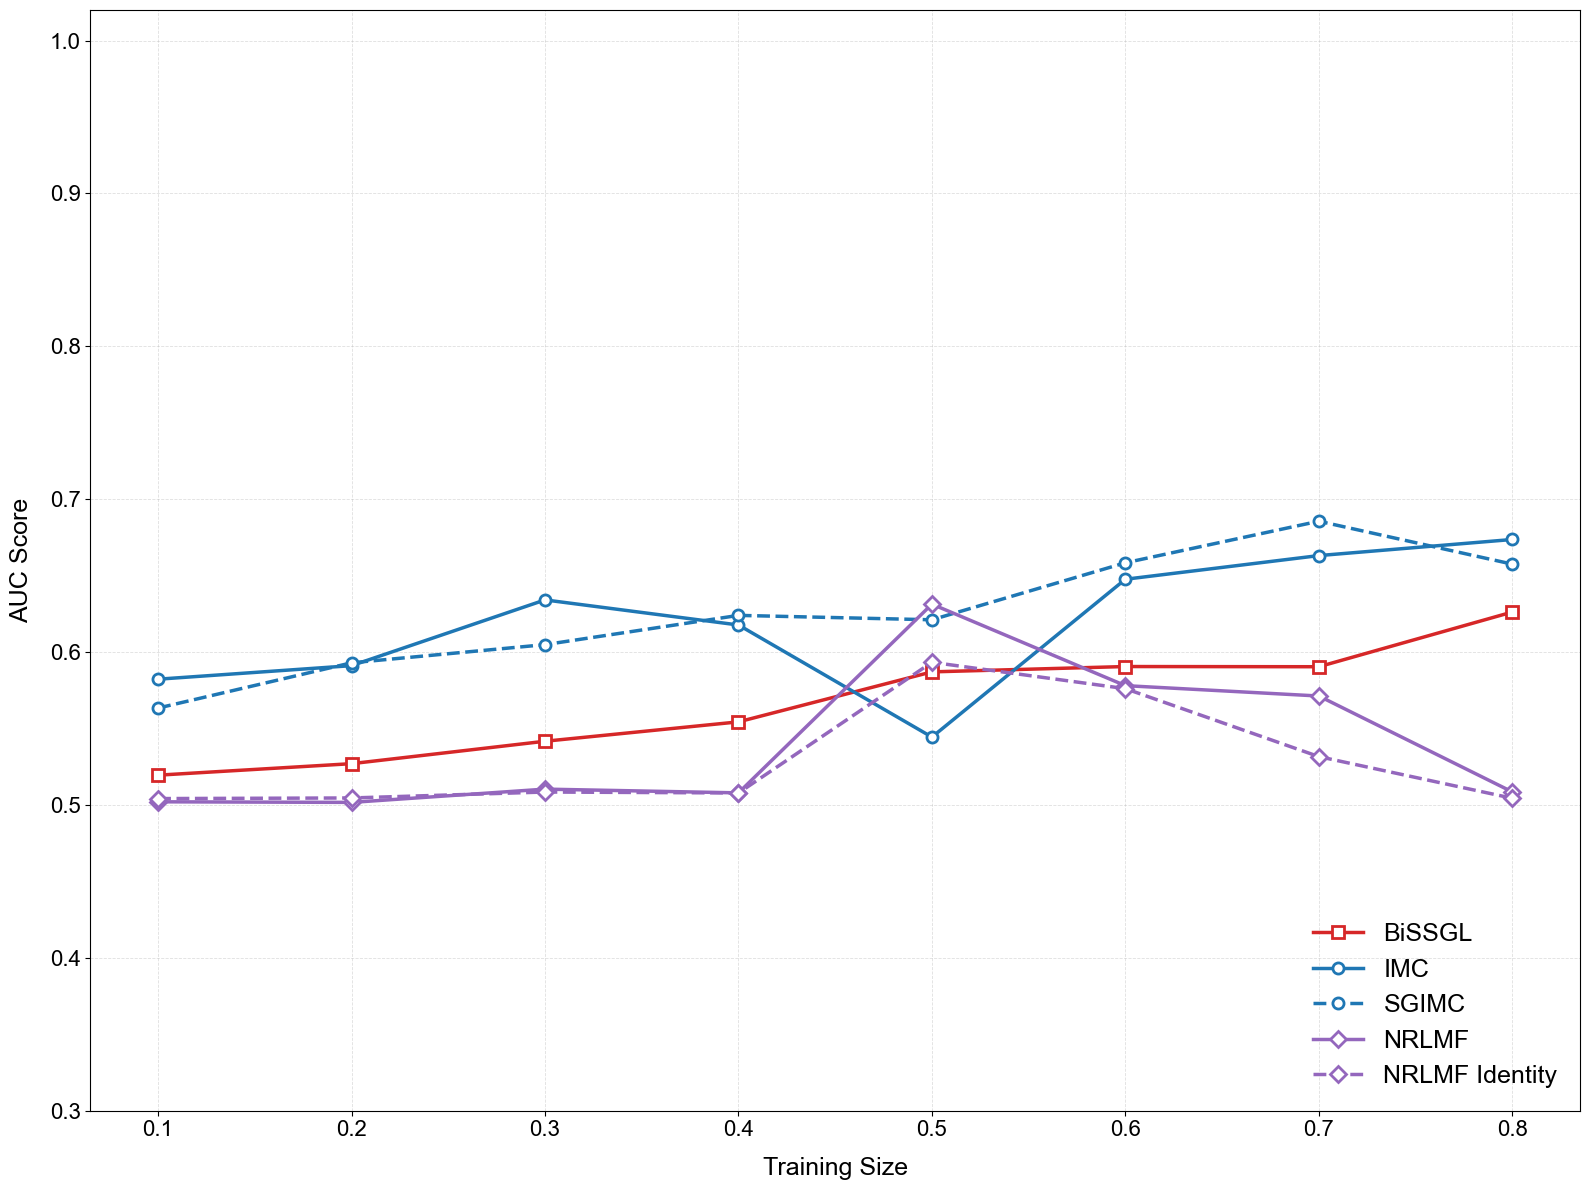

In [37]:
# Better display

import matplotlib.pyplot as plt

METHOD_STYLE = {
    "IMC": dict(color="tab:blue", linestyle="-", marker="o"),
    "SGIMC": dict(color="tab:blue", linestyle="--", marker="o"),
    "BiSSGL": dict(color="tab:red", linestyle="-", marker="s"),
    "DRIMC": dict(color="tab:green", linestyle="-", marker="^"),
    "DRIMC Identity": dict(color="tab:green", linestyle="--", marker="^"),
    "NRLMF": dict(color="tab:purple", linestyle="-", marker="D"),
    "NRLMF Identity": dict(color="tab:purple", linestyle="--", marker="D"),
}

plt.rcParams.update(
    {
        "font.family": "sans-serif",
        "font.sans-serif": ["Arial", "Helvetica"],
    }
)

plt.figure(figsize=(16, 12))

# Curves + markers (single call each)
plt.plot(
    results_bissgl[0],
    results_bissgl[1],
    label="BiSSGL",
    linewidth=2.5,
    markersize=8,
    markerfacecolor="white",
    markeredgewidth=2,
    **METHOD_STYLE["BiSSGL"],
)

plt.plot(
    results_imc[0],
    results_imc[1],
    label="IMC",
    linewidth=2.5,
    markersize=8,
    markerfacecolor="white",
    markeredgewidth=2,
    **METHOD_STYLE["IMC"],
)

plt.plot(
    results_sgimc[0],
    results_sgimc[1],
    label="SGIMC",
    linewidth=2.5,
    markersize=8,
    markerfacecolor="white",
    markeredgewidth=2,
    **METHOD_STYLE["SGIMC"],
)

# plt.plot(
#     results_drimc[0],
#     results_drimc[1],
#     label="DRIMC",
#     linewidth=2.5,
#     markersize=8,
#     markerfacecolor="white",
#     markeredgewidth=2,
#     **METHOD_STYLE["DRIMC"],
# )

# plt.plot(
#     results_drimc_identity[0],
#     results_drimc_identity[1],
#     label="DRIMC Identity",
#     linewidth=2.5,
#     markersize=8,
#     markerfacecolor="white",
#     markeredgewidth=2,
#     **METHOD_STYLE["DRIMC Identity"],
# )

plt.plot(
    results_nrlmf[0],
    results_nrlmf[1],
    label="NRLMF",
    linewidth=2.5,
    markersize=8,
    markerfacecolor="white",
    markeredgewidth=2,
    **METHOD_STYLE["NRLMF"],
)

plt.plot(
    results_nrlmf_identity[0],
    results_nrlmf_identity[1],
    label="NRLMF Identity",
    linewidth=2.5,
    markersize=8,
    markerfacecolor="white",
    markeredgewidth=2,
    **METHOD_STYLE["NRLMF Identity"],
)

# Axis limits and labels
plt.ylim(0.3, 1.02)
plt.xlabel("Training Size", fontsize=18, labelpad=12)
plt.ylabel("AUC Score", fontsize=18, labelpad=12)

# Ticks
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)

# Light grid (optional but modern)
plt.grid(
    True,
    which="major",
    linestyle="--",
    linewidth=0.6,
    alpha=0.4,
)

# Legend
plt.legend(
    fontsize=18,
    loc="lower right",
    frameon=False,
)

plt.tight_layout()
# plt.show()
plt.savefig(
    os.path.join(PATH_FIGURE, "roc_auc_comparison.pdf"),
    format="pdf",
    bbox_inches="tight",
)
plt.show()
plt.close()

---

## Case 2: noisy

In [38]:
PATH_ROOT = "/Users/sijianfan/projects/BiSSGL"
PATH_DATA = os.path.join(PATH_ROOT, "datasets/realAnalysis/cdataset/cv_data")

PATH_OUTPUT = os.path.join(PATH_ROOT, "outputs/results/realAnalysis/cdataset/noisy")

if not os.path.isdir(PATH_OUTPUT):
    os.makedirs(PATH_OUTPUT)

PATH_ARCHIVE = os.path.join(PATH_OUTPUT, "archived")
if not os.path.isdir(PATH_ARCHIVE):
    os.makedirs(PATH_ARCHIVE)

### BiSSGL

In [215]:
filename_results = []
filename_results.append(os.path.join(PATH_OUTPUT, "results_bissgl.gz"))

# for fn in os.listdir(PATH_ARCHIVE):
#     filename_results.append(os.path.join(PATH_ARCHIVE, fn))

filename_results

['/Users/sijianfan/projects/BiSSGL/outputs/results/realAnalysis/cdataset/noisy/results_bissgl.gz']

In [216]:
results = []
for fn in filename_results:
    results.append(load(fn))

In [217]:
results

[[{'combo_idx': 0,
   'train_size': 0.1,
   'xi': 1,
   'eta': 1e-06,
   'tilde_lambda0': 5,
   'tilde_lambda1': 1,
   'lambda0': 5,
   'lambda1': 1,
   'K': 50,
   'cv': 0,
   'val_score': [0.12807939524510498,
    0.621089557382699,
    0.03215434083601286,
    0.776332899869961,
    0.5263157894736842,
    0.7781103835360149,
    0.01658374792703151],
   'val_d1': 1888,
   'val_d2': 797,
   'test_score': [0.12945220071013594,
    0.6184817430043097,
    0.038139076113759655,
    0.7825957715602125,
    0.42028985507246375,
    0.7863498141682622,
    0.01997589116583434],
   'test_d1': 1887,
   'test_d2': 797},
  {'combo_idx': 0,
   'train_size': 0.1,
   'xi': 1,
   'eta': 1e-06,
   'tilde_lambda0': 5,
   'tilde_lambda1': 1,
   'lambda0': 5,
   'lambda1': 1,
   'K': 50,
   'cv': 1,
   'val_score': [0.08216188863352246,
    0.6118282392649541,
    0.037383177570093455,
    0.7703882593349434,
    0.48,
    0.7731108194262142,
    0.019448946515397084],
   'val_d1': 1885,
   'val_d2':

In [163]:
from collections import defaultdict
import numpy as np

def get_final_results(results, param="train_size", hyp_param="xi", target="auc"):

    metric_idx = METRIC_INDEX[target]

    # =====================================================
    # 1️⃣ Collapse CV folds → group by combo_idx
    # =====================================================
    by_combo = defaultdict(list)

    for r in results:
        by_combo[r["combo_idx"]].append(r)

    combo_summary = []

    for combo_idx, group in by_combo.items():
        # same params within combo
        p_val = group[0][param]
        hp_val = group[0][hyp_param] if hyp_param is not None else None

        val_vals = [g["val_score"][metric_idx] for g in group]
        val_mean = np.nanmean(val_vals)

        test_val = group[0]["test_score"][metric_idx]

        combo_summary.append([
            combo_idx,
            p_val,
            hp_val,
            val_mean,
            test_val
        ])

    combo_summary = np.array(combo_summary, dtype=object)
    # columns:
    # 0 combo_idx
    # 1 param (train_size)
    # 2 hyp_param
    # 3 val_mean
    # 4 test_metric

    # =====================================================
    # 2️⃣ Select best combo per param value
    # =====================================================
    by_param = defaultdict(list)

    for row in combo_summary:
        by_param[row[1]].append(row)

    results_final = []

    for p_val, rows in by_param.items():
        rows = np.array(rows, dtype=object)

        # select best via validation
        val_scores = rows[:, 3].astype(float)
        best = rows[np.nanargmax(val_scores)]

        # store param and corresponding test score
        results_final.append([p_val, float(best[4])])

    results_final = np.array(results_final, dtype=float)

    # =====================================================
    # 3️⃣ Sort for plotting
    # =====================================================
    order = np.argsort(results_final[:, 0])
    results_final = results_final[order]

    return results_final.T

In [230]:
results_bissgl = get_final_results(
    results[0],
    param="train_size",
    hyp_params=['combo_idx'],
    target="auc",
)

In [231]:
results_bissgl

array([[0.1       , 0.2       , 0.3       , 0.4       , 0.5       ,
        0.6       , 0.7       , 0.8       ],
       [0.61997165, 0.72496937, 0.76024142, 0.80413407, 0.81907379,
        0.84444774, 0.85002038, 0.8635163 ]])

### IMC

In [196]:
filename_results = []
filename_results.append(os.path.join(PATH_OUTPUT, "results_imc.gz"))

# for fn in os.listdir(PATH_ARCHIVE):
#     filename_results.append(os.path.join(PATH_ARCHIVE, fn))

filename_results

['/Users/sijianfan/projects/BiSSGL/outputs/results/realAnalysis/cdataset/noisy/results_imc.gz']

In [197]:
results = []
for fn in filename_results:
    results.append(load(fn))

In [210]:
from collections import defaultdict
import numpy as np

def get_final_results(results,
                      param="train_size",
                      hyp_params=None,
                      target="auc"):

    metric_idx = METRIC_INDEX[target]

    if hyp_params is None:
        hyp_params = []

    # =====================================================
    # 1️⃣ Collapse CV folds → group by full model identity
    # =====================================================
    by_model = defaultdict(list)

    for r in results:
        key = tuple([r[param]] + [r[h] for h in hyp_params])
        by_model[key].append(r)

    model_summary = []

    for key, group in by_model.items():
        p_val = key[0]

        val_vals = [g["val_score"][metric_idx] for g in group]
        val_mean = np.nanmean(val_vals)

        test_val = group[0]["test_score"][metric_idx]

        model_summary.append([p_val, val_mean, test_val])

    model_summary = np.array(model_summary, dtype=float)
    # columns: [param, val_mean, test_metric]

    # =====================================================
    # 2️⃣ Select best model per param
    # =====================================================
    by_param = defaultdict(list)

    for row in model_summary:
        by_param[row[0]].append(row)

    results_final = []

    for p_val, rows in by_param.items():
        rows = np.array(rows)
        best = rows[np.nanargmax(rows[:, 1])]  # select by val_mean
        results_final.append([p_val, best[2]])

    results_final = np.array(results_final)

    # =====================================================
    # 3️⃣ Sort for plotting
    # =====================================================
    order = np.argsort(results_final[:, 0])
    results_final = results_final[order]

    return results_final.T

In [211]:
results

[[{'train_size': 0.1,
   'lamb': 1.0,
   'rank': 50,
   'cv': 0,
   'val_score': [0.15289334716398878,
    0.639069941871367,
    0.04411764705882353,
    0.8309492847854356,
    0.42,
    0.834802175135946,
    0.02328159645232816],
   'test_score': [0.14858057864842,
    0.6712390145798832,
    0.04264735465701066,
    0.8231709582729536,
    0.4326530612244898,
    0.8267586620668966,
    0.022429115531104528]},
  {'train_size': 0.1,
   'lamb': 1.0,
   'rank': 50,
   'cv': 1,
   'val_score': [0.1361258513500644,
    0.6822049815991544,
    0.0515625,
    0.774475199702768,
    0.559322033898305,
    0.7768595041322314,
    0.02702702702702703],
   'test_score': [0.14858057864842,
    0.6712390145798832,
    0.04264735465701066,
    0.8231709582729536,
    0.4326530612244898,
    0.8267586620668966,
    0.022429115531104528]},
  {'train_size': 0.1,
   'lamb': 1.0,
   'rank': 50,
   'cv': 2,
   'val_score': [0.11477660193623365,
    0.695605776444111,
    0.04198473282442748,
    0.81

In [213]:
results_imc = get_final_results(
    results[0],
    param="train_size",
    hyp_params=["lamb","rank"],
    target="auc",
)

In [214]:
results_imc

array([[0.1       , 0.2       , 0.3       , 0.4       , 0.5       ,
        0.6       , 0.7       , 0.8       ],
       [0.66224719, 0.70477741, 0.74560866, 0.76906864, 0.7835648 ,
        0.79052866, 0.75987234, 0.81407718]])

### SGIMC

In [178]:
filename_results = []
filename_results.append(os.path.join(PATH_OUTPUT, "results_sgimc.gz"))

# for fn in os.listdir(PATH_ARCHIVE):
#     filename_results.append(os.path.join(PATH_ARCHIVE, fn))

filename_results

['/Users/sijianfan/projects/BiSSGL/outputs/results/realAnalysis/cdataset/noisy/results_sgimc.gz']

In [179]:
results = []
for fn in filename_results:
    results.append(load(fn))

In [180]:
results

[[{'combo_idx': 0,
   'train_size': 0.1,
   'C_lasso': 5.0,
   'C_group': 5.0,
   'C_ridge': 1.0,
   'cv': 0,
   'val_score': [0.11135375062518568,
    0.4934173600512038,
    0.015177478580171358,
    0.25264722273825,
    0.8157894736842105,
    0.24864359214218895,
    0.0076599950580677045],
   'val_d1': 22,
   'val_d2': 4,
   'test_score': [0.505127633485676,
    0.5,
    0.020302328147412556,
    0.010255266971352135,
    1.0,
    0.0,
    0.010255266971352135],
   'test_d1': 0,
   'test_d2': 0},
  {'combo_idx': 0,
   'train_size': 0.1,
   'C_lasso': 5.0,
   'C_group': 5.0,
   'C_ridge': 1.0,
   'cv': 1,
   'val_score': [0.5046442504179826,
    0.5,
    0.018406037180195105,
    0.009288500835965075,
    1.0,
    0.0,
    0.009288500835965075],
   'val_d1': 0,
   'val_d2': 0,
   'test_score': [0.505127633485676,
    0.5,
    0.020302328147412556,
    0.010255266971352135,
    1.0,
    0.0,
    0.010255266971352135],
   'test_d1': 0,
   'test_d2': 0},
  {'combo_idx': 0,
   'train_

In [184]:
results_sgimc = get_final_results(
    results[0],
    param="train_size",
    # hyp_param="C_group",
    hyp_param=None,
    target="auc",
)

In [185]:
results_sgimc

array([[0.1       , 0.2       , 0.3       , 0.4       , 0.5       ,
        0.6       , 0.7       , 0.8       ],
       [0.62464975, 0.6654673 , 0.73529981, 0.76202295, 0.77077073,
        0.77262721, 0.78217656, 0.79615298]])

### DRIMC

In [150]:
filename_results = []
filename_results.append(os.path.join(PATH_OUTPUT, "results_drimc.gz"))

# for fn in os.listdir(PATH_ARCHIVE):
#     filename_results.append(os.path.join(PATH_ARCHIVE, fn))

filename_results

['/Users/sijianfan/projects/BiSSGL/outputs/results/realAnalysis/cdataset/noisy/results_drimc.gz']

In [103]:
results = []
for fn in filename_results:
    results.append(load(fn))

In [104]:
results

[[{'train_size': 0.1,
   'lamU': 2,
   'lamV': 2,
   'cc': 1,
   'iterpara': 0.125,
   'numLat': 200,
   'test_score': [0.005671498743792416,
    0.5116635977007958,
    0.019397651863195507,
    0.8572437112176272,
    0.16593886462882096,
    0.8631764353170439,
    0.010300894551368935],
   'test_d1': 658,
   'test_d2': 409},
  {'train_size': 0.1,
   'lamU': 2,
   'lamV': 2,
   'cc': 3,
   'iterpara': 0.125,
   'numLat': 200,
   'test_score': [0.005678995419160208,
    0.5117355214743605,
    0.019432773109243698,
    0.8612566417716345,
    0.1615720524017467,
    0.8672612801678908,
    0.010338083263481419],
   'test_d1': 658,
   'test_d2': 409},
  {'train_size': 0.1,
   'lamU': 2,
   'lamV': 2,
   'cc': 5,
   'iterpara': 0.125,
   'numLat': 200,
   'test_score': [0.0056761503697964144,
    0.5117537683475173,
    0.01955085865257596,
    0.8621112473525805,
    0.1615720524017467,
    0.8681232199070604,
    0.010404949381327334],
   'test_d1': 658,
   'test_d2': 409},
  {'train

In [105]:
results_drimc = get_test_results(
    results[0],
    param="train_size",
    hyp_param="cc",
    target="auc",
)

In [106]:
results_drimc

array([[0.1       , 0.2       , 0.3       , 0.4       , 0.5       ,
        0.6       , 0.7       , 0.8       ],
       [0.51177864, 0.51177332, 0.51189541, 0.51180957, 0.51186939,
        0.51182356, 0.51186922, 0.51184738]])

In [107]:
filename_results = []
filename_results.append(os.path.join(PATH_OUTPUT, "results_drimc_identity.gz"))
results = []
for fn in filename_results:
    results.append(load(fn))
results_drimc_identity = get_test_results(
    results[0],
    param="train_size",
    hyp_param="cc",
    target="auc",
)
results_drimc_identity

array([[0.1       , 0.2       , 0.3       , 0.4       , 0.5       ,
        0.6       , 0.7       , 0.8       ],
       [0.68814164, 0.7525281 , 0.78572343, 0.82288155, 0.86173826,
        0.87237384, 0.89609607, 0.91839774]])

### NRLMF

In [108]:
filename_results = []
filename_results.append(os.path.join(PATH_OUTPUT, "results_nrlmf.gz"))

# for fn in os.listdir(PATH_ARCHIVE):
#     filename_results.append(os.path.join(PATH_ARCHIVE, fn))

filename_results

['/Users/sijianfan/projects/BiSSGL/outputs/results/realAnalysis/cdataset/noisy/results_nrlmf.gz']

In [109]:
results = []
for fn in filename_results:
    results.append(load(fn))

In [110]:
results

[[{'train_size': 0.1,
   'lambda_d': 0.125,
   'lambda_t': 0.125,
   'c': 1,
   'r': 50,
   'test_score': [0.007389338186916924,
    0.5081525515560957,
    0.02753441802252816,
    0.9711291940697804,
    0.044897959183673466,
    0.9796385180740963,
    0.019855595667870037],
   'test_d1': 658,
   'test_d2': 409},
  {'train_size': 0.1,
   'lambda_d': 0.125,
   'lambda_t': 0.125,
   'c': 1,
   'r': 200,
   'test_score': [0.02444216131698628,
    0.5170265976497093,
    0.0546448087431694,
    0.9871437595214209,
    0.04081632653061224,
    0.9958377081145943,
    0.08264462809917356],
   'test_d1': 658,
   'test_d2': 409},
  {'train_size': 0.1,
   'lambda_d': 0.125,
   'lambda_t': 0.125,
   'c': 3,
   'r': 50,
   'test_score': [0.007832957541483372,
    0.5083617757887616,
    0.03379416282642089,
    0.9766283951993461,
    0.044897959183673466,
    0.9851882405879706,
    0.027093596059113302],
   'test_d1': 658,
   'test_d2': 409},
  {'train_size': 0.1,
   'lambda_d': 0.125,
   'l

In [111]:
results_nrlmf = get_test_results(
    results[0],
    param="train_size",
    hyp_param="c",
    target="auc",
)

In [112]:
results_nrlmf

array([[0.1       , 0.2       , 0.3       , 0.4       , 0.5       ,
        0.6       , 0.7       , 0.8       ],
       [0.51702943, 0.51464562, 0.5156485 , 0.51571248, 0.5168662 ,
        0.51645923, 0.51567483, 0.51645464]])

In [113]:
filename_results = []
filename_results.append(os.path.join(PATH_OUTPUT, "results_nrlmf_identity.gz"))
results = []
for fn in filename_results:
    results.append(load(fn))
results_nrlmf_identity = get_test_results(
    results[0],
    param="train_size",
    hyp_param="c",
    target="auc",
)
results_nrlmf_identity

array([[0.1       , 0.2       , 0.3       , 0.4       , 0.5       ,
        0.6       , 0.7       , 0.8       ],
       [0.66987035, 0.69751857, 0.78973073, 0.79759176, 0.84064187,
        0.87556088, 0.90131431, 0.9109545 ]])

---

### Plot figures

In [114]:
PATH_FIGURE = os.path.join(PATH_ROOT, "outputs/figures/realAnalysis/cdataset")

if not os.path.isdir(PATH_FIGURE):
    os.makedirs(PATH_FIGURE)

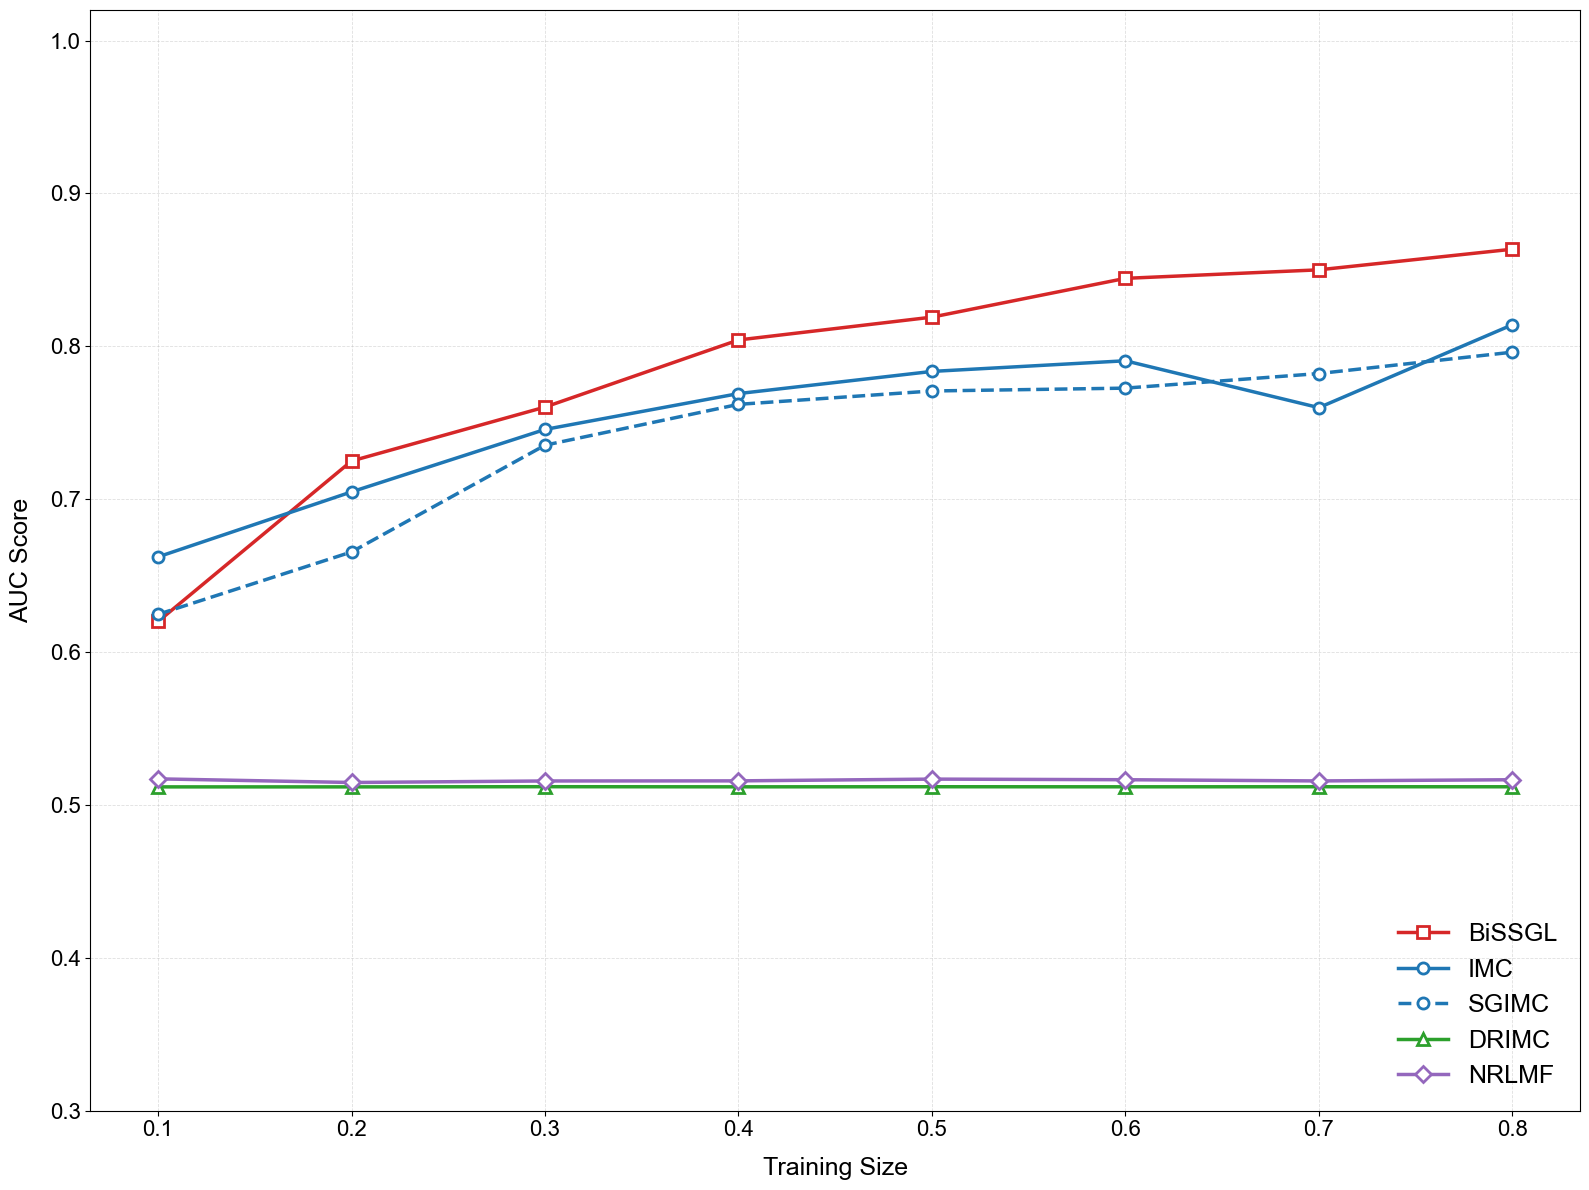

In [233]:
# Better display

import matplotlib.pyplot as plt

METHOD_STYLE = {
    "IMC": dict(color="tab:blue", linestyle="-", marker="o"),
    "SGIMC": dict(color="tab:blue", linestyle="--", marker="o"),
    "BiSSGL": dict(color="tab:red", linestyle="-", marker="s"),
    "DRIMC": dict(color="tab:green", linestyle="-", marker="^"),
    "DRIMC Identity": dict(color="tab:green", linestyle="--", marker="^"),
    "NRLMF": dict(color="tab:purple", linestyle="-", marker="D"),
    "NRLMF Identity": dict(color="tab:purple", linestyle="--", marker="D"),
}

plt.rcParams.update(
    {
        "font.family": "sans-serif",
        "font.sans-serif": ["Arial", "Helvetica"],
    }
)

plt.figure(figsize=(16, 12))

# Curves + markers (single call each)
plt.plot(
    results_bissgl[0],
    results_bissgl[1],
    label="BiSSGL",
    linewidth=2.5,
    markersize=8,
    markerfacecolor="white",
    markeredgewidth=2,
    **METHOD_STYLE["BiSSGL"],
)

plt.plot(
    results_imc[0],
    results_imc[1],
    label="IMC",
    linewidth=2.5,
    markersize=8,
    markerfacecolor="white",
    markeredgewidth=2,
    **METHOD_STYLE["IMC"],
)

plt.plot(
    results_sgimc[0],
    results_sgimc[1],
    label="SGIMC",
    linewidth=2.5,
    markersize=8,
    markerfacecolor="white",
    markeredgewidth=2,
    **METHOD_STYLE["SGIMC"],
)

plt.plot(
    results_drimc[0],
    results_drimc[1],
    label="DRIMC",
    linewidth=2.5,
    markersize=8,
    markerfacecolor="white",
    markeredgewidth=2,
    **METHOD_STYLE["DRIMC"],
)

# plt.plot(
#     results_drimc_identity[0],
#     results_drimc_identity[1],
#     label="DRIMC Identity",
#     linewidth=2.5,
#     markersize=8,
#     markerfacecolor="white",
#     markeredgewidth=2,
#     **METHOD_STYLE["DRIMC Identity"],
# )

plt.plot(
    results_nrlmf[0],
    results_nrlmf[1],
    label="NRLMF",
    linewidth=2.5,
    markersize=8,
    markerfacecolor="white",
    markeredgewidth=2,
    **METHOD_STYLE["NRLMF"],
)

# plt.plot(
#     results_nrlmf_identity[0],
#     results_nrlmf_identity[1],
#     label="NRLMF Identity",
#     linewidth=2.5,
#     markersize=8,
#     markerfacecolor="white",
#     markeredgewidth=2,
#     **METHOD_STYLE["NRLMF Identity"],
# )

# Axis limits and labels
plt.ylim(0.3, 1.02)
plt.xlabel("Training Size", fontsize=18, labelpad=12)
plt.ylabel("AUC Score", fontsize=18, labelpad=12)

# Ticks
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)

# Light grid (optional but modern)
plt.grid(
    True,
    which="major",
    linestyle="--",
    linewidth=0.6,
    alpha=0.4,
)

# Legend
plt.legend(
    fontsize=18,
    loc="lower right",
    frameon=False,
)

plt.tight_layout()
# plt.show()
plt.savefig(
    os.path.join(PATH_FIGURE, "roc_auc_comparison.pdf"),
    format="pdf",
    bbox_inches="tight",
)
plt.show()
plt.close()

---

#### Extra plots

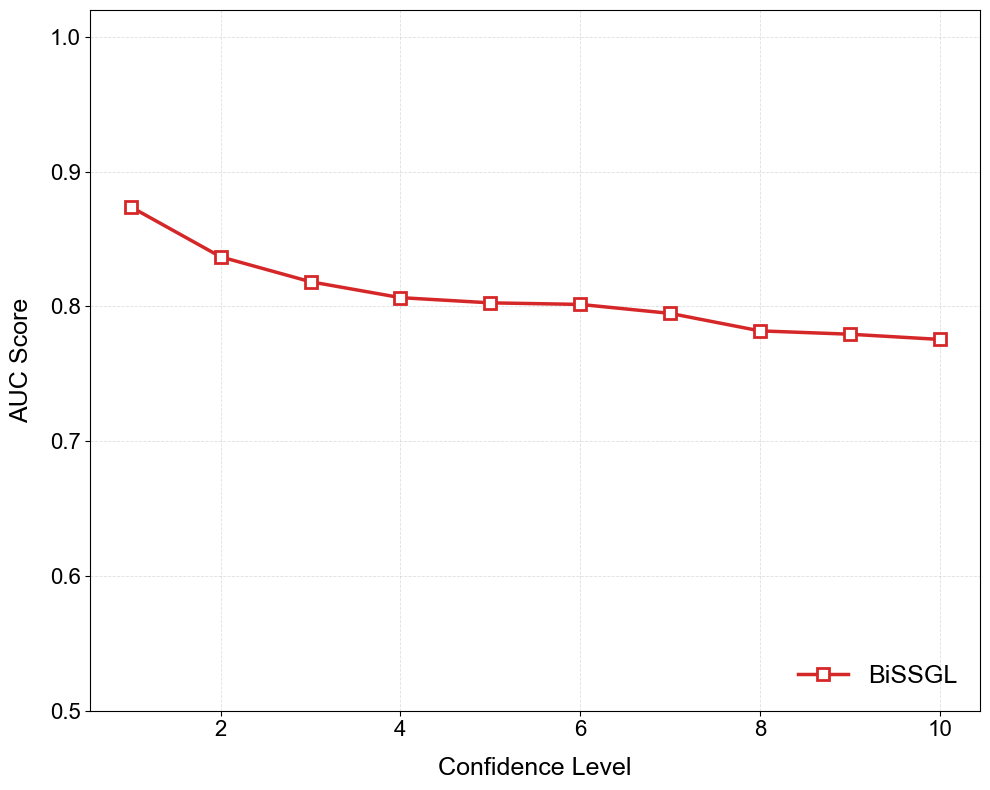

In [ ]:
# Better display

import matplotlib.pyplot as plt

METHOD_STYLE = {
    "IMC": dict(color="tab:blue", linestyle="-", marker="o"),
    "SGIMC": dict(color="tab:blue", linestyle="--", marker="o"),
    "BiSSGL": dict(color="tab:red", linestyle="-", marker="s"),
    "DRIMC": dict(color="tab:green", linestyle="-", marker="^"),
    "NRLMF": dict(color="tab:purple", linestyle="-", marker="D"),
}

plt.rcParams.update(
    {
        "font.family": "sans-serif",
        "font.sans-serif": ["Arial", "Helvetica"],
    }
)

plt.figure(figsize=(10, 8))

# Curves + markers (single call each)
# plt.plot(
#     results_bissgl_xi[0],
#     results_bissgl_xi[1],
#     label="BiSSGL",
#     linewidth=2.5,
#     markersize=8,
#     markerfacecolor="white",
#     markeredgewidth=2,
#     **METHOD_STYLE["BiSSGL"],
# )

# Axis limits and labels
plt.ylim(0.5, 1.02)
plt.xlabel("Confidence Level", fontsize=18, labelpad=12)
plt.ylabel("AUC Score", fontsize=18, labelpad=12)

# Ticks
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)

# Light grid (optional but modern)
plt.grid(
    True,
    which="major",
    linestyle="--",
    linewidth=0.6,
    alpha=0.4,
)

# Legend
plt.legend(
    fontsize=18,
    loc="lower right",
    frameon=False,
)

plt.tight_layout()
# plt.show()
plt.savefig(
    os.path.join(PATH_FIGURE, "roc_auc_confidence_noisy.pdf"),
    format="pdf",
    bbox_inches="tight",
)
plt.show()
plt.close()

This is the BiSSGL in a random run with just identity matrix:

[{'train_size': 0.81,
  'xi': 10,
  'eta': 0.001,
  'tilde_lambda0': 10,
  'tilde_lambda1': 1,
  'lambda0': 10,
  'lambda1': 1,
  'K': 200,
  'test_score': [0.5976584761181942,
   **0.9209463761505803,**
   0.6160520607375272,
   0.9934232527031546,
   0.5795918367346938,
   0.9972251387430628,
   0.6574074074074074],
  'test_d1': 658,
  'test_d2': 409}]